In [10]:
# Determinants of Bank Profitability in Morocco

## 1) Data Preparation
""" This notebook loads, inspects, and prepares the panel dataset used to analyse the determinants of Moroccan banks' profitability between 2013 and 2022. The dataset contains five banks observed over ten years, resulting in 50 bank-year observations."""

" This notebook loads, inspects, and prepares the panel dataset used to analyse the determinants of Moroccan banks' profitability between 2013 and 2022. The dataset contains five banks observed over ten years, resulting in 50 bank-year observations."

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [12]:
from google.colab import files

uploaded = files.upload()

Saving Base De Donnée Final PFE.xlsx to Base De Donnée Final PFE (1).xlsx


In [13]:
uploaded_filename = list(uploaded.keys())[0]

if uploaded_filename.lower().endswith(tuple([".xlsx", ".xls"])):
    df = pd.read_excel(uploaded_filename, sheet_name="ROA")

elif uploaded_filename.lower().endswith(".csv"):
    df = pd.read_csv(uploaded_filename)

else:
    raise ValueError("Please upload an Excel or CSV file.")

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded successfully.
Dataset shape: 81 rows and 9 columns


In [14]:
df

,ANNEE,BANQUES,ROA,CNE,RCNP,ADC,TB,TC,TMIC
0,2013.0000,1.0000,1.3139,40.1799,1.5521,9.8385,8.5861,4.5354,14.3000
1,2014.0000,1.0000,1.2792,39.4905,1.7661,10.0542,8.6041,19.0473,14.3900
2,2015.0000,1.0000,1.2893,41.8990,1.8574,10.0295,8.6139,4.3446,14.3800
3,2016.0000,1.0000,1.3185,41.9192,1.8994,11.0576,8.6322,0.5212,14.3000
4,2017.0000,1.0000,1.3965,-41.7817,1.6961,10.7749,8.6735,5.0579,13.9000
...,...,...,...,...,...,...,...,...,...
76,NaN,NaN,2018,3.0656,NaN,NaN,NaN,NaN,NaN
77,NaN,NaN,2019,2.8910,NaN,NaN,NaN,NaN,NaN
78,NaN,NaN,2020,-7.1871,NaN,NaN,NaN,NaN,NaN
79,NaN,NaN,2021,7.9297,NaN,NaN,NaN,NaN,NaN


In [15]:
df = df.dropna()

In [16]:
df

,ANNEE,BANQUES,ROA,CNE,RCNP,ADC,TB,TC,TMIC
0,2013.0000,1.0000,1.3139,40.1799,1.5521,9.8385,8.5861,4.5354,14.3000
1,2014.0000,1.0000,1.2792,39.4905,1.7661,10.0542,8.6041,19.0473,14.3900
2,2015.0000,1.0000,1.2893,41.8990,1.8574,10.0295,8.6139,4.3446,14.3800
3,2016.0000,1.0000,1.3185,41.9192,1.8994,11.0576,8.6322,0.5212,14.3000
4,2017.0000,1.0000,1.3965,-41.7817,1.6961,10.7749,8.6735,5.0579,13.9000
5,2018.0000,1.0000,1.3732,-43.1272,2.0716,10.2904,8.6906,3.0656,13.6000
6,2019.0000,1.0000,0.6956,-41.2347,1.9325,10.1248,8.7264,2.8910,13.5700
7,2020.0000,1.0000,0.6522,-44.5047,2.1880,9.5568,8.7544,-7.1871,13.5200
8,2021.0000,1.0000,1.0324,-40.4359,2.4631,10.0268,8.7755,7.9297,13.3600
9,2022.0000,1.0000,1.1831,-39.0143,1.9776,9.8546,8.7996,3.2000,13.0900


In [17]:
# Définir les index du panel
df2 = df.set_index(['BANQUES', 'ANNEE'])

# Afficher les premières lignes
df2

ROA      CNE   RCNP      ADC     TB      TC    TMIC
BANQUES ANNEE                                                            
1.0000  2013.0000  1.3139  40.1799 1.5521   9.8385 8.5861  4.5354 14.3000
        2014.0000  1.2792  39.4905 1.7661  10.0542 8.6041 19.0473 14.3900
        2015.0000  1.2893  41.8990 1.8574  10.0295 8.6139  4.3446 14.3800
        2016.0000  1.3185  41.9192 1.8994  11.0576 8.6322  0.5212 14.3000
        2017.0000  1.3965 -41.7817 1.6961  10.7749 8.6735  5.0579 13.9000
        2018.0000  1.3732 -43.1272 2.0716  10.2904 8.6906  3.0656 13.6000
        2019.0000  0.6956 -41.2347 1.9325  10.1248 8.7264  2.8910 13.5700
        2020.0000  0.6522 -44.5047 2.1880   9.5568 8.7544 -7.1871 13.5200
        2021.0000  1.0324 -40.4359 2.4631  10.0268 8.7755  7.9297 13.3600
        2022.0000  1.1831 -39.0143 1.9776   9.8546 8.7996  3.2000 13.0900
2.0000  2013.0000  1.2410  50.3057 8.2023  11.5637 7.6175  4.5354 14.3000
        2014.0000  1.1591  53.7630 7.7148  11.3633 7.6349 19.0473 14.3900
        2015.0000  1.1915  53.2851 7.2414  11.1404 7.6523  4.3446 14.3800
        2016.0000  0.9271  52.7673 6.9417  10.7289 7.6805  0.5212 14.3000
        2017.0000  0.7880  58.9166 7.0596   9.8719 7.7293  5.0579 13.9000
        2018.0000  0.6302  57.2181 8.6357   7.8860 7.8126  3.0656 13.6000
        2019.0000  0.5334 -55.7516 3.7217   7.3036 7.8758  2.8910 13.5700
        2020.0000  0.0499 -55.5711 3.7209   6.0561 7.9521 -7.1871 13.5200
        2021.0000  0.5845 -50.1676 3.3922   5.4941 8.0270  7.9297 13.3600
        2022.0000  0.6068 -47.1719 3.1739   6.0458 8.0688  3.2000 13.0900
3.0000  2013.0000  1.1043 -43.6213 1.4798  11.8725 8.4628  4.5354 14.3000
        2014.0000  1.0515 -41.1271 1.6569  11.2146 8.4908 19.0473 14.3900
        2015.0000  0.9193 -43.4559 2.4462  11.8115 8.5170  4.3446 14.3800
        2016.0000  0.8638 -44.8060 2.0709  11.7627 8.5462  0.5212 14.3000
        2017.0000  1.2703 -45.4563 1.8556  11.3373 8.5838  5.0579 13.9000
        2018.0000  1.3030 -45.4563 1.7681  10.4436 8.5983  3.0656 13.6000
        2019.0000  0.9012 -44.3949 2.0687  10.8950 8.6349  2.8910 13.5700
        2020.0000  0.2888 -49.6183 2.4907  10.6856 8.6477 -7.1871 13.5200
        2021.0000  0.5861 -43.2449 2.4907  11.1424 8.6675  7.9297 13.3600
        2022.0000  0.7015 -45.6035 2.8821  11.1981 8.6995  3.2000 13.0900
4.0000  2013.0000  0.9568  41.8740 2.8232  12.6737 7.8262  4.5354 14.3000
        2014.0000  0.5511  43.0862 3.5534  12.8910 7.8213 19.0473 14.3900
        2015.0000  0.8017  42.8786 4.4784  13.8527 7.7959  4.3446 14.3800
        2016.0000  0.6717  46.4403 3.9042  13.4939 7.8091  0.5212 14.3000
        2017.0000  0.8305  46.4679 3.1760  13.0627 7.8177  5.0579 13.9000
        2018.0000  0.8104  47.4434 2.9599  10.4792 7.8408  3.0656 13.6000
        2019.0000 49.8708  46.7939 2.3484 623.2100 6.0803  2.8910 13.5700
        2020.0000  0.2174  49.5663 2.5678  11.4872 7.8235 -7.1871 13.5200
        2021.0000  0.2467  61.9256 2.7298  10.7299 7.8300  7.9297 13.3600
        2022.0000  0.2613  60.1572 2.5210  10.2867 7.8498  3.2000 13.0900
5.0000  2013.0000  0.7945 -53.5877 1.7889   8.0878 8.3742  4.5354 14.3000
        2014.0000  1.0889 -50.6884 1.7477   8.4141 8.3931 19.0473 14.3900
        2015.0000  0.9501 -52.9857 2.0809   7.9126 8.4463  4.3446 14.3800
        2016.0000  0.9266 -51.4122 1.8175   7.7087 8.4856  0.5212 14.3000
        2017.0000  0.9076 -52.4799 2.1870   7.8777 8.4960  5.0579 13.9000
        2018.0000  0.9503 -54.3684 2.1940   8.0669 8.4706  3.0656 13.6000
        2019.0000  8.1584 -51.3525 2.6366  88.0322 7.4993  2.8910 13.5700
        2020.0000  0.4109 -56.0328 2.8869   8.4301 8.5210 -7.1871 13.5200
        2021.0000  0.8258 -47.2924 3.5101   8.5490 8.5379  7.9297 13.3600
        2022.0000  0.9240 -46.8418 3.7447   8.3104 8.5834  3.2000 13.0900

In [18]:
df2.index = df2.index.set_levels(df2.index.levels[1].astype(int), level='ANNEE')
df2.index = df2.index.set_levels(df2.index.levels[0].astype(int), level='BANQUES')

In [19]:
df2

ROA      CNE   RCNP      ADC     TB      TC    TMIC
BANQUES ANNEE                                                        
1       2013   1.3139  40.1799 1.5521   9.8385 8.5861  4.5354 14.3000
        2014   1.2792  39.4905 1.7661  10.0542 8.6041 19.0473 14.3900
        2015   1.2893  41.8990 1.8574  10.0295 8.6139  4.3446 14.3800
        2016   1.3185  41.9192 1.8994  11.0576 8.6322  0.5212 14.3000
        2017   1.3965 -41.7817 1.6961  10.7749 8.6735  5.0579 13.9000
        2018   1.3732 -43.1272 2.0716  10.2904 8.6906  3.0656 13.6000
        2019   0.6956 -41.2347 1.9325  10.1248 8.7264  2.8910 13.5700
        2020   0.6522 -44.5047 2.1880   9.5568 8.7544 -7.1871 13.5200
        2021   1.0324 -40.4359 2.4631  10.0268 8.7755  7.9297 13.3600
        2022   1.1831 -39.0143 1.9776   9.8546 8.7996  3.2000 13.0900
2       2013   1.2410  50.3057 8.2023  11.5637 7.6175  4.5354 14.3000
        2014   1.1591  53.7630 7.7148  11.3633 7.6349 19.0473 14.3900
        2015   1.1915  53.2851 7.2414  11.1404 7.6523  4.3446 14.3800
        2016   0.9271  52.7673 6.9417  10.7289 7.6805  0.5212 14.3000
        2017   0.7880  58.9166 7.0596   9.8719 7.7293  5.0579 13.9000
        2018   0.6302  57.2181 8.6357   7.8860 7.8126  3.0656 13.6000
        2019   0.5334 -55.7516 3.7217   7.3036 7.8758  2.8910 13.5700
        2020   0.0499 -55.5711 3.7209   6.0561 7.9521 -7.1871 13.5200
        2021   0.5845 -50.1676 3.3922   5.4941 8.0270  7.9297 13.3600
        2022   0.6068 -47.1719 3.1739   6.0458 8.0688  3.2000 13.0900
3       2013   1.1043 -43.6213 1.4798  11.8725 8.4628  4.5354 14.3000
        2014   1.0515 -41.1271 1.6569  11.2146 8.4908 19.0473 14.3900
        2015   0.9193 -43.4559 2.4462  11.8115 8.5170  4.3446 14.3800
        2016   0.8638 -44.8060 2.0709  11.7627 8.5462  0.5212 14.3000
        2017   1.2703 -45.4563 1.8556  11.3373 8.5838  5.0579 13.9000
        2018   1.3030 -45.4563 1.7681  10.4436 8.5983  3.0656 13.6000
        2019   0.9012 -44.3949 2.0687  10.8950 8.6349  2.8910 13.5700
        2020   0.2888 -49.6183 2.4907  10.6856 8.6477 -7.1871 13.5200
        2021   0.5861 -43.2449 2.4907  11.1424 8.6675  7.9297 13.3600
        2022   0.7015 -45.6035 2.8821  11.1981 8.6995  3.2000 13.0900
4       2013   0.9568  41.8740 2.8232  12.6737 7.8262  4.5354 14.3000
        2014   0.5511  43.0862 3.5534  12.8910 7.8213 19.0473 14.3900
        2015   0.8017  42.8786 4.4784  13.8527 7.7959  4.3446 14.3800
        2016   0.6717  46.4403 3.9042  13.4939 7.8091  0.5212 14.3000
        2017   0.8305  46.4679 3.1760  13.0627 7.8177  5.0579 13.9000
        2018   0.8104  47.4434 2.9599  10.4792 7.8408  3.0656 13.6000
        2019  49.8708  46.7939 2.3484 623.2100 6.0803  2.8910 13.5700
        2020   0.2174  49.5663 2.5678  11.4872 7.8235 -7.1871 13.5200
        2021   0.2467  61.9256 2.7298  10.7299 7.8300  7.9297 13.3600
        2022   0.2613  60.1572 2.5210  10.2867 7.8498  3.2000 13.0900
5       2013   0.7945 -53.5877 1.7889   8.0878 8.3742  4.5354 14.3000
        2014   1.0889 -50.6884 1.7477   8.4141 8.3931 19.0473 14.3900
        2015   0.9501 -52.9857 2.0809   7.9126 8.4463  4.3446 14.3800
        2016   0.9266 -51.4122 1.8175   7.7087 8.4856  0.5212 14.3000
        2017   0.9076 -52.4799 2.1870   7.8777 8.4960  5.0579 13.9000
        2018   0.9503 -54.3684 2.1940   8.0669 8.4706  3.0656 13.6000
        2019   8.1584 -51.3525 2.6366  88.0322 7.4993  2.8910 13.5700
        2020   0.4109 -56.0328 2.8869   8.4301 8.5210 -7.1871 13.5200
        2021   0.8258 -47.2924 3.5101   8.5490 8.5379  7.9297 13.3600
        2022   0.9240 -46.8418 3.7447   8.3104 8.5834  3.2000 13.0900

In [20]:
df2.dtypes

,0
ROA,object
CNE,object
RCNP,float64
ADC,float64
TB,float64
TC,float64
TMIC,float64


In [21]:
# Mapping: ID -> Bank name
bank_id_to_name = {
    1: 'Attijariwafa',
    2: 'CIH bank',
    3: 'BCP bank',
    4: 'BMCI bank',
    5: 'BMCE bank'
}

# Rename the BANQUES index values
df2 = df2.rename(index=bank_id_to_name, level='BANQUES')

In [22]:
df2

ROA      CNE   RCNP      ADC     TB      TC    TMIC
BANQUES      ANNEE                                                        
Attijariwafa 2013   1.3139  40.1799 1.5521   9.8385 8.5861  4.5354 14.3000
             2014   1.2792  39.4905 1.7661  10.0542 8.6041 19.0473 14.3900
             2015   1.2893  41.8990 1.8574  10.0295 8.6139  4.3446 14.3800
             2016   1.3185  41.9192 1.8994  11.0576 8.6322  0.5212 14.3000
             2017   1.3965 -41.7817 1.6961  10.7749 8.6735  5.0579 13.9000
             2018   1.3732 -43.1272 2.0716  10.2904 8.6906  3.0656 13.6000
             2019   0.6956 -41.2347 1.9325  10.1248 8.7264  2.8910 13.5700
             2020   0.6522 -44.5047 2.1880   9.5568 8.7544 -7.1871 13.5200
             2021   1.0324 -40.4359 2.4631  10.0268 8.7755  7.9297 13.3600
             2022   1.1831 -39.0143 1.9776   9.8546 8.7996  3.2000 13.0900
CIH bank     2013   1.2410  50.3057 8.2023  11.5637 7.6175  4.5354 14.3000
             2014   1.1591  53.7630 7.7148  11.3633 7.6349 19.0473 14.3900
             2015   1.1915  53.2851 7.2414  11.1404 7.6523  4.3446 14.3800
             2016   0.9271  52.7673 6.9417  10.7289 7.6805  0.5212 14.3000
             2017   0.7880  58.9166 7.0596   9.8719 7.7293  5.0579 13.9000
             2018   0.6302  57.2181 8.6357   7.8860 7.8126  3.0656 13.6000
             2019   0.5334 -55.7516 3.7217   7.3036 7.8758  2.8910 13.5700
             2020   0.0499 -55.5711 3.7209   6.0561 7.9521 -7.1871 13.5200
             2021   0.5845 -50.1676 3.3922   5.4941 8.0270  7.9297 13.3600
             2022   0.6068 -47.1719 3.1739   6.0458 8.0688  3.2000 13.0900
BCP bank     2013   1.1043 -43.6213 1.4798  11.8725 8.4628  4.5354 14.3000
             2014   1.0515 -41.1271 1.6569  11.2146 8.4908 19.0473 14.3900
             2015   0.9193 -43.4559 2.4462  11.8115 8.5170  4.3446 14.3800
             2016   0.8638 -44.8060 2.0709  11.7627 8.5462  0.5212 14.3000
             2017   1.2703 -45.4563 1.8556  11.3373 8.5838  5.0579 13.9000
             2018   1.3030 -45.4563 1.7681  10.4436 8.5983  3.0656 13.6000
             2019   0.9012 -44.3949 2.0687  10.8950 8.6349  2.8910 13.5700
             2020   0.2888 -49.6183 2.4907  10.6856 8.6477 -7.1871 13.5200
             2021   0.5861 -43.2449 2.4907  11.1424 8.6675  7.9297 13.3600
             2022   0.7015 -45.6035 2.8821  11.1981 8.6995  3.2000 13.0900
BMCI bank    2013   0.9568  41.8740 2.8232  12.6737 7.8262  4.5354 14.3000
             2014   0.5511  43.0862 3.5534  12.8910 7.8213 19.0473 14.3900
             2015   0.8017  42.8786 4.4784  13.8527 7.7959  4.3446 14.3800
             2016   0.6717  46.4403 3.9042  13.4939 7.8091  0.5212 14.3000
             2017   0.8305  46.4679 3.1760  13.0627 7.8177  5.0579 13.9000
             2018   0.8104  47.4434 2.9599  10.4792 7.8408  3.0656 13.6000
             2019  49.8708  46.7939 2.3484 623.2100 6.0803  2.8910 13.5700
             2020   0.2174  49.5663 2.5678  11.4872 7.8235 -7.1871 13.5200
             2021   0.2467  61.9256 2.7298  10.7299 7.8300  7.9297 13.3600
             2022   0.2613  60.1572 2.5210  10.2867 7.8498  3.2000 13.0900
BMCE bank    2013   0.7945 -53.5877 1.7889   8.0878 8.3742  4.5354 14.3000
             2014   1.0889 -50.6884 1.7477   8.4141 8.3931 19.0473 14.3900
             2015   0.9501 -52.9857 2.0809   7.9126 8.4463  4.3446 14.3800
             2016   0.9266 -51.4122 1.8175   7.7087 8.4856  0.5212 14.3000
             2017   0.9076 -52.4799 2.1870   7.8777 8.4960  5.0579 13.9000
             2018   0.9503 -54.3684 2.1940   8.0669 8.4706  3.0656 13.6000
             2019   8.1584 -51.3525 2.6366  88.0322 7.4993  2.8910 13.5700
             2020   0.4109 -56.0328 2.8869   8.4301 8.5210 -7.1871 13.5200
             2021   0.8258 -47.2924 3.5101   8.5490 8.5379  7.9297 13.3600
             2022   0.9240 -46.8418 3.7447   8.3104 8.5834  3.2000 13.0900

In [23]:
# Display the dimensions of the dataset
print("Dataset dimensions")
print(f"Number of observations: {df2.shape[0]}")
print(f"Number of variables: {df2.shape[1]}")

Dataset dimensions
Number of observations: 50
Number of variables: 7


In [24]:
# Display information about the dataset
print("Dataset information")
df2.info()

Dataset information
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 50 entries, ('Attijariwafa', np.int64(2013)) to ('BMCE bank', np.int64(2022))
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ROA     50 non-null     object 
 1   CNE     50 non-null     object 
 2   RCNP    50 non-null     float64
 3   ADC     50 non-null     float64
 4   TB      50 non-null     float64
 5   TC      50 non-null     float64
 6   TMIC    50 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.5+ KB


In [25]:
# Display the data types of each variable
print("Data types")
display(df2.dtypes)

Data types


,0
ROA,object
CNE,object
RCNP,float64
ADC,float64
TB,float64
TC,float64
TMIC,float64


In [26]:
df2['ROA'] = pd.to_numeric(df2['ROA'], errors='raise')
df2['CNE'] = pd.to_numeric(df2['CNE'], errors='raise')

In [27]:
print(df2[['ROA', 'CNE']].dtypes)

ROA    float64
CNE    float64
dtype: object


In [28]:
df2.dtypes

,0
ROA,float64
CNE,float64
RCNP,float64
ADC,float64
TB,float64
TC,float64
TMIC,float64


In [29]:
# Check for missing values
missing_values = pd.DataFrame({
    "Missing Values": df2.isnull().sum(),
    "Percentage (%)": (df2.isnull().mean() * 100).round(2)
})

print("Missing values summary")
display(missing_values)

Missing values summary


,Missing Values,Percentage (%)
ROA,0,0.0000
CNE,0,0.0000
RCNP,0,0.0000
ADC,0,0.0000
TB,0,0.0000
TC,0,0.0000
TMIC,0,0.0000


In [30]:
print("Total missing values remaining:", df2.isnull().sum().sum())

Total missing values remaining: 0


In [31]:
# Check duplicated observations
duplicates = df2.duplicated().sum()

print(f"Number of duplicated observations: {duplicates}")

Number of duplicated observations: 0


In [32]:
df2

ROA      CNE   RCNP      ADC     TB      TC    TMIC
BANQUES      ANNEE                                                        
Attijariwafa 2013   1.3139  40.1799 1.5521   9.8385 8.5861  4.5354 14.3000
             2014   1.2792  39.4905 1.7661  10.0542 8.6041 19.0473 14.3900
             2015   1.2893  41.8990 1.8574  10.0295 8.6139  4.3446 14.3800
             2016   1.3185  41.9192 1.8994  11.0576 8.6322  0.5212 14.3000
             2017   1.3965 -41.7817 1.6961  10.7749 8.6735  5.0579 13.9000
             2018   1.3732 -43.1272 2.0716  10.2904 8.6906  3.0656 13.6000
             2019   0.6956 -41.2347 1.9325  10.1248 8.7264  2.8910 13.5700
             2020   0.6522 -44.5047 2.1880   9.5568 8.7544 -7.1871 13.5200
             2021   1.0324 -40.4359 2.4631  10.0268 8.7755  7.9297 13.3600
             2022   1.1831 -39.0143 1.9776   9.8546 8.7996  3.2000 13.0900
CIH bank     2013   1.2410  50.3057 8.2023  11.5637 7.6175  4.5354 14.3000
             2014   1.1591  53.7630 7.7148  11.3633 7.6349 19.0473 14.3900
             2015   1.1915  53.2851 7.2414  11.1404 7.6523  4.3446 14.3800
             2016   0.9271  52.7673 6.9417  10.7289 7.6805  0.5212 14.3000
             2017   0.7880  58.9166 7.0596   9.8719 7.7293  5.0579 13.9000
             2018   0.6302  57.2181 8.6357   7.8860 7.8126  3.0656 13.6000
             2019   0.5334 -55.7516 3.7217   7.3036 7.8758  2.8910 13.5700
             2020   0.0499 -55.5711 3.7209   6.0561 7.9521 -7.1871 13.5200
             2021   0.5845 -50.1676 3.3922   5.4941 8.0270  7.9297 13.3600
             2022   0.6068 -47.1719 3.1739   6.0458 8.0688  3.2000 13.0900
BCP bank     2013   1.1043 -43.6213 1.4798  11.8725 8.4628  4.5354 14.3000
             2014   1.0515 -41.1271 1.6569  11.2146 8.4908 19.0473 14.3900
             2015   0.9193 -43.4559 2.4462  11.8115 8.5170  4.3446 14.3800
             2016   0.8638 -44.8060 2.0709  11.7627 8.5462  0.5212 14.3000
             2017   1.2703 -45.4563 1.8556  11.3373 8.5838  5.0579 13.9000
             2018   1.3030 -45.4563 1.7681  10.4436 8.5983  3.0656 13.6000
             2019   0.9012 -44.3949 2.0687  10.8950 8.6349  2.8910 13.5700
             2020   0.2888 -49.6183 2.4907  10.6856 8.6477 -7.1871 13.5200
             2021   0.5861 -43.2449 2.4907  11.1424 8.6675  7.9297 13.3600
             2022   0.7015 -45.6035 2.8821  11.1981 8.6995  3.2000 13.0900
BMCI bank    2013   0.9568  41.8740 2.8232  12.6737 7.8262  4.5354 14.3000
             2014   0.5511  43.0862 3.5534  12.8910 7.8213 19.0473 14.3900
             2015   0.8017  42.8786 4.4784  13.8527 7.7959  4.3446 14.3800
             2016   0.6717  46.4403 3.9042  13.4939 7.8091  0.5212 14.3000
             2017   0.8305  46.4679 3.1760  13.0627 7.8177  5.0579 13.9000
             2018   0.8104  47.4434 2.9599  10.4792 7.8408  3.0656 13.6000
             2019  49.8708  46.7939 2.3484 623.2100 6.0803  2.8910 13.5700
             2020   0.2174  49.5663 2.5678  11.4872 7.8235 -7.1871 13.5200
             2021   0.2467  61.9256 2.7298  10.7299 7.8300  7.9297 13.3600
             2022   0.2613  60.1572 2.5210  10.2867 7.8498  3.2000 13.0900
BMCE bank    2013   0.7945 -53.5877 1.7889   8.0878 8.3742  4.5354 14.3000
             2014   1.0889 -50.6884 1.7477   8.4141 8.3931 19.0473 14.3900
             2015   0.9501 -52.9857 2.0809   7.9126 8.4463  4.3446 14.3800
             2016   0.9266 -51.4122 1.8175   7.7087 8.4856  0.5212 14.3000
             2017   0.9076 -52.4799 2.1870   7.8777 8.4960  5.0579 13.9000
             2018   0.9503 -54.3684 2.1940   8.0669 8.4706  3.0656 13.6000
             2019   8.1584 -51.3525 2.6366  88.0322 7.4993  2.8910 13.5700
             2020   0.4109 -56.0328 2.8869   8.4301 8.5210 -7.1871 13.5200
             2021   0.8258 -47.2924 3.5101   8.5490 8.5379  7.9297 13.3600
             2022   0.9240 -46.8418 3.7447   8.3104 8.5834  3.2000 13.0900

In [34]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df2)

https://docs.google.com/spreadsheets/d/1aOClxt7MQLul6go8Gl2-FyICKahK6lMnGm4I0cK-E00/edit#gid=0


In [ ]:
# 2) Exploratory Data Analysis

## Objective
"""
This notebook explores the cleaned panel dataset on the determinants of bank profitability in Morocco.

The analysis focuses on:

- descriptive statistics,
- variable distributions,
- potential outliers,
- correlations between variables,
- profitability differences across banks,
- profitability trends over time."""

In [36]:
variables = ['ROA', 'CNE', 'RCNP', 'ADC', 'TB', 'TC', 'TMIC']
descriptive_statistics = df2[variables].describe().T

descriptive_statistics = descriptive_statistics.rename(
    columns={
        "count": "Observations",
        "mean": "Mean",
        "std": "Standard deviation",
        "min": "Minimum",
        "25%": "First quartile",
        "50%": "Median",
        "75%": "Third quartile",
        "max": "Maximum"
    }
)

display(descriptive_statistics)

,Observations,Mean,Standard deviation,Minimum,First quartile,Median,Third quartile,Maximum
ROA,50.0000,1.9878,6.9942,0.0499,0.6571,0.9134,1.1771,49.8708
CNE,50.0000,-8.9242,47.9810,-56.0328,-47.2623,-42.4544,45.6017,61.9256
RCNP,50.0000,3.1215,1.8335,1.4798,1.9438,2.4907,3.4806,8.6357
ADC,50.0000,23.8996,87.2050,5.4941,8.4598,10.4614,11.3568,623.2100
TB,50.0000,8.2212,0.5098,6.0803,7.8242,8.4667,8.6026,8.7996
TC,50.0000,4.3406,6.2452,-7.1871,2.8910,3.7723,5.0579,19.0473
TMIC,50.0000,13.8410,0.4570,13.0900,13.5200,13.7500,14.3000,14.3900


In [38]:
# Exploration des données
!pip install ydata-profiling
from ydata_profiling import ProfileReport
# Profilage pour GLE
ProfileReport(df2, minimal=True, explorative=True).to_notebook_iframe()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.6 MB/s eta 0:00:00


/tmp/ipykernel_1645/1997600516.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00, 433.91it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [39]:
additional_statistics = pd.DataFrame({
    "Mean": df2[variables].mean(),
    "Median": df2[variables].median(),
    "Standard deviation": df2[variables].std(),
    "Variance": df2[variables].var(),
    "Skewness": df2[variables].skew(),
    "Kurtosis": df2[variables].kurt()
})

display(additional_statistics)

,Mean,Median,Standard deviation,Variance,Skewness,Kurtosis
ROA,1.9878,0.9134,6.9942,48.9192,6.8303,47.4946
CNE,-8.9242,-42.4544,47.9810,2302.1793,0.4265,-1.8253
RCNP,3.1215,2.4907,1.8335,3.3618,1.8678,2.6038
ADC,23.8996,10.4614,87.2050,7604.7110,6.9044,48.2720
TB,8.2212,8.4667,0.5098,0.2599,-1.6012,4.6152
TC,4.3406,3.7723,6.2452,39.0024,0.7127,1.7225
TMIC,13.8410,13.7500,0.4570,0.2088,-0.0959,-1.4606


In [40]:
average_by_bank = (
    df2[variables]
    .groupby(level="BANQUES")
    .mean()
)

display(average_by_bank)

,ROA,CNE,RCNP,ADC,TB,TC,TMIC
BANQUES,,,,,,,
Attijariwafa,1.1534,-8.6610,1.9404,10.1608,8.6856,4.3406,13.8410
BCP bank,0.8990,-44.6784,2.1210,11.2363,8.5849,4.3406,13.8410
BMCE bank,1.5937,-51.7042,2.4594,16.1390,8.3807,4.3406,13.8410
BMCI bank,5.5218,48.6633,3.1062,73.2167,7.6495,4.3406,13.8410
CIH bank,0.7711,11.7594,5.9804,8.7454,7.8051,4.3406,13.8410


In [41]:
average_roa_by_bank = (
    df2["ROA"]
    .groupby(level="BANQUES")
    .mean()
    .sort_values(ascending=False)
)

display(average_roa_by_bank)

,ROA
BANQUES,
BMCI bank,5.5218
BMCE bank,1.5937
Attijariwafa,1.1534
BCP bank,0.8990
CIH bank,0.7711


In [42]:
average_by_year = (
    df2[variables]
    .groupby(level="ANNEE")
    .mean()
)

display(average_by_year)

,ROA,CNE,RCNP,ADC,TB,TC,TMIC
ANNEE,,,,,,,
2013,1.0821,7.0301,3.1692,10.8072,8.1734,4.5354,14.3000
2014,1.0260,8.9048,3.2878,10.7874,8.1888,19.0473,14.3900
2015,1.0304,8.3242,3.6209,10.9493,8.2051,4.3446,14.3800
2016,0.9416,8.9817,3.3267,10.9504,8.2307,0.5212,14.3000
2017,1.0386,-6.8667,3.1949,10.5849,8.2601,5.0579,13.9000
2018,1.0134,-7.6581,3.5259,9.4332,8.2826,3.0656,13.6000
2019,12.0319,-29.1879,2.5416,147.9131,7.7634,2.8910,13.5700
2020,0.3238,-31.2321,2.7709,9.2432,8.3398,-7.1871,13.5200
2021,0.6551,-23.8430,2.9172,9.1884,8.3676,7.9297,13.3600


In [43]:
average_roa_by_year = (
    df2["ROA"]
    .groupby(level="ANNEE")
    .mean()
)

display(average_roa_by_year)

,ROA
ANNEE,
2013,1.0821
2014,1.0260
2015,1.0304
2016,0.9416
2017,1.0386
2018,1.0134
2019,12.0319
2020,0.3238
2021,0.6551


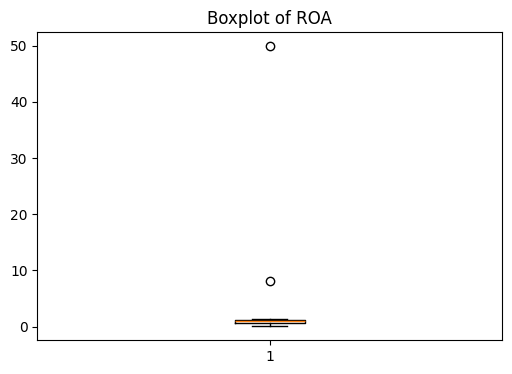

In [44]:
plt.figure(figsize=(6,4))
plt.boxplot(df2["ROA"])
plt.title("Boxplot of ROA")
plt.show()

In [45]:
corr = df2.corr(numeric_only=True)

display(corr)

,ROA,CNE,RCNP,ADC,TB,TC,TMIC
ROA,1.0000,0.1477,-0.0696,0.9986,-0.6186,-0.0199,-0.0756
CNE,0.1477,1.0000,0.5109,0.1609,-0.5899,0.1521,0.3042
RCNP,-0.0696,0.5109,1.0000,-0.0642,-0.5041,0.0504,0.1154
ADC,0.9986,0.1609,-0.0642,1.0000,-0.6310,-0.0345,-0.0875
TB,-0.6186,-0.5899,-0.5041,-0.6310,1.0000,-0.0306,-0.0768
TC,-0.0199,0.1521,0.0504,-0.0345,-0.0306,1.0000,0.3570
TMIC,-0.0756,0.3042,0.1154,-0.0875,-0.0768,0.3570,1.0000


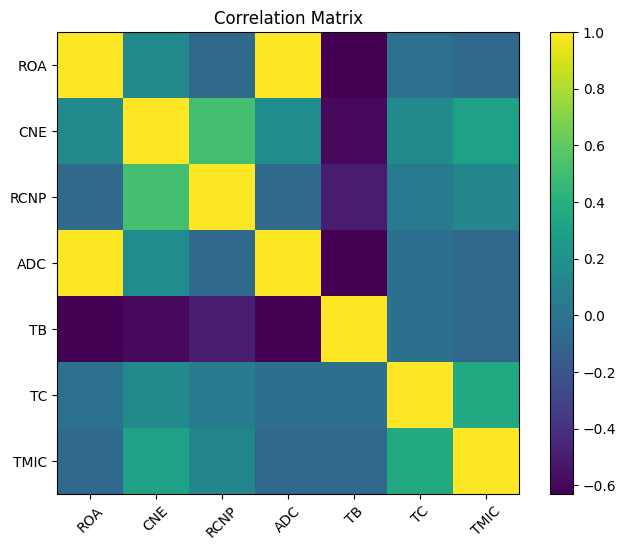

In [46]:
plt.figure(figsize=(8,6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

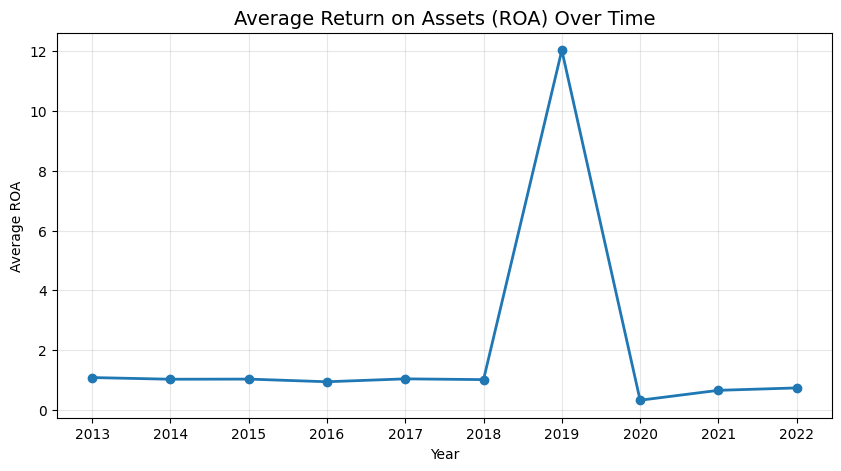

In [49]:
# Average ROA by year
roa_year = df2.groupby(level="ANNEE")["ROA"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    roa_year.index,
    roa_year.values,
    marker='o',
    linewidth=2
)

plt.title("Average Return on Assets (ROA) Over Time", fontsize=14)
plt.xlabel("Year")
plt.ylabel("Average ROA")
plt.grid(True, alpha=0.3)

plt.xticks(roa_year.index)

plt.show()

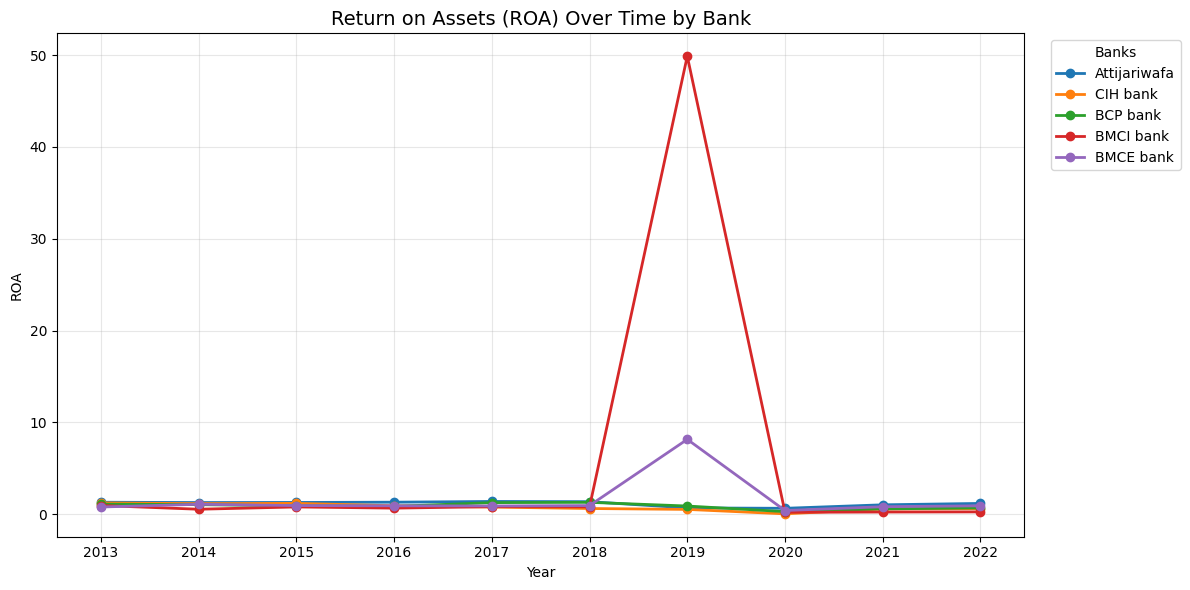

In [50]:
plt.figure(figsize=(12,6))

for bank in df2.index.get_level_values("BANQUES").unique():

    bank_data = df2.xs(bank, level="BANQUES")

    plt.plot(
        bank_data.index,
        bank_data["ROA"],
        marker='o',
        linewidth=2,
        label=bank
    )

plt.title("Return on Assets (ROA) Over Time by Bank", fontsize=14)

plt.xlabel("Year")
plt.ylabel("ROA")

plt.xticks(bank_data.index)

plt.legend(title="Banks", bbox_to_anchor=(1.02,1), loc="upper left")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

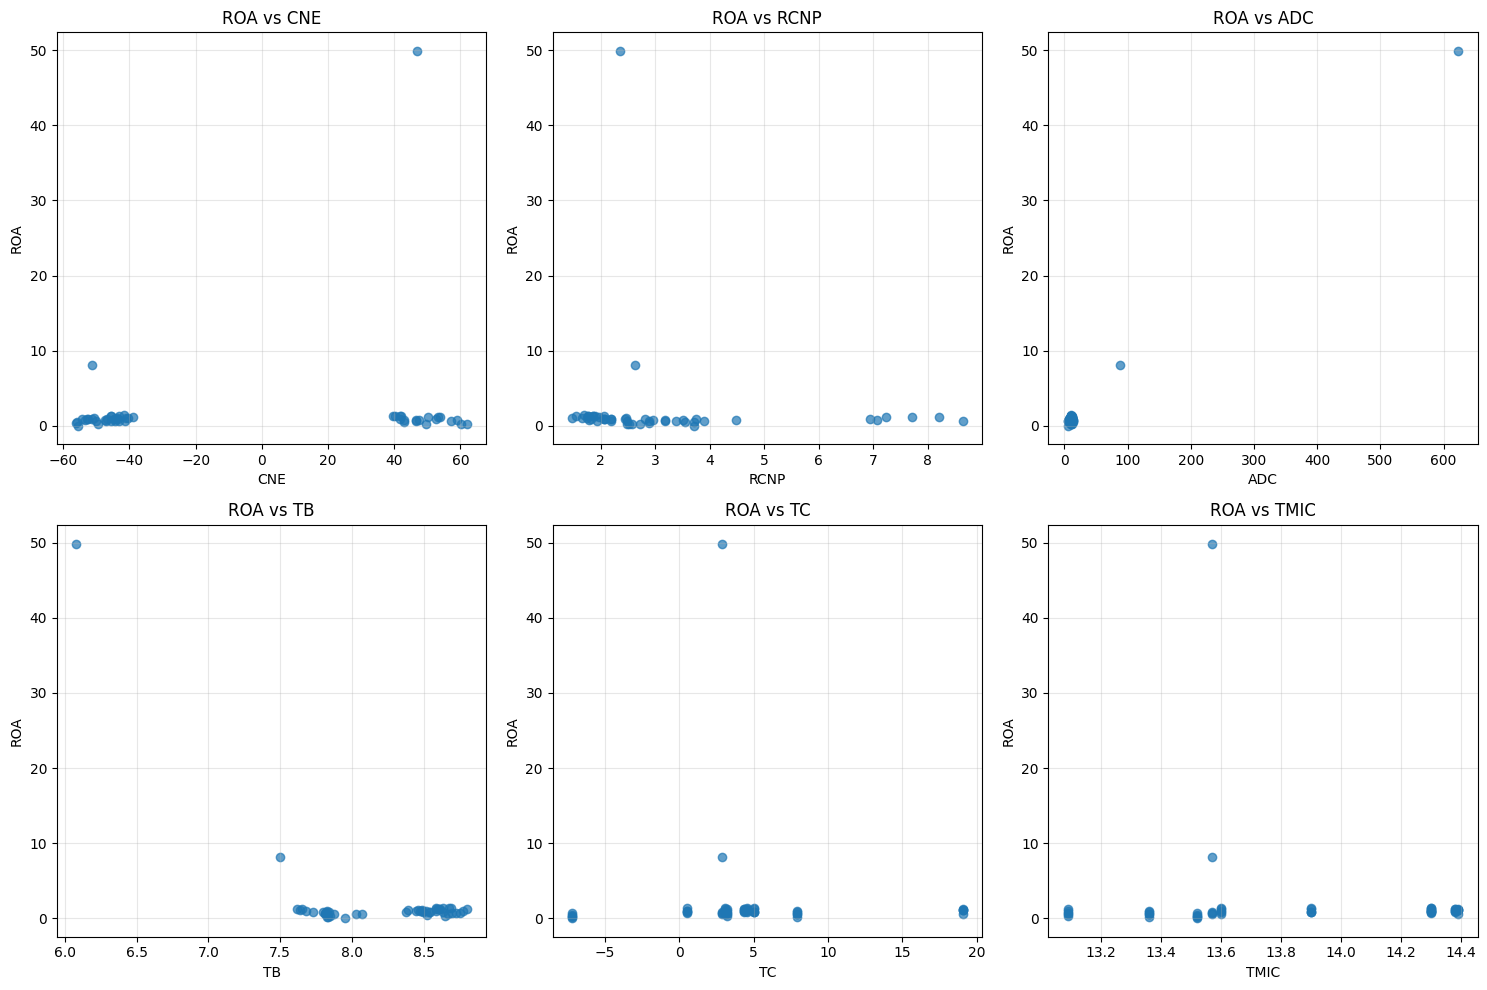

In [51]:
variables = [
    "CNE",
    "RCNP",
    "ADC",
    "TB",
    "TC",
    "TMIC"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for ax, variable in zip(axes, variables):

    ax.scatter(
        df2[variable],
        df2["ROA"],
        alpha=0.7
    )

    ax.set_title(f"ROA vs {variable}")

    ax.set_xlabel(variable)

    ax.set_ylabel("ROA")

    ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()